# Data Visualization in Python with Matplotlib, Seaborn, and Streamlit

## 🧩 General Objective
- Learn how to create effective data visualizations using Matplotlib and Seaborn.
- Build a simple web application with Streamlit.
- Upload the project to GitHub to share or deploy it.


| Objective                         | Data Type                              | Recommended Chart Type                      |
|----------------------------------|----------------------------------------|---------------------------------------------|
| Distribution of a variable       | Continuous/Discrete Numerical          | Histogram, KDE, Boxplot                     |
| Compare categories               | Categorical vs. Numerical              | Boxplot, Violinplot, Barplot                |
| Compare values by category       | Nominal Categorical vs. Numerical      | Barplot, Countplot                          |
| Time trends                      | Date + Numerical Variable              | Line plot                                   |
| Correlation between two variables| Two Numerical Variables                | Scatter plot, Heatmap (for many variables)  |
| Cross between two categoricals   | Two Categorical Variables              | Heatmap, Countplot with hue                 |


In [51]:
#!pip install streamlit

In [52]:
import streamlit as st

st.title("Mi Primera Aplicación con Streamlit")
st.write("¡Hola mundo!")

# Agregar un widget interactivo
nombre = st.text_input("Escribe tu nombre")
if nombre:
    st.write(f"Hola, {nombre}!")

2025-04-09 01:09:59.992 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-09 01:10:00.334 
  command:

    streamlit run C:\Users\melor\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-04-09 01:10:00.335 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-09 01:10:00.337 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-09 01:10:00.337 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-09 01:10:00.339 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-09 01:10:00.341 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-09 01:10:00.341 Thread 'MainThread': mi

## 1. Quantities: 
This type of graph shows the levels of variables. Also, these graphs show the variables according to categories or classifications.

In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

Matplotlib is building the font cache; this may take a moment.


Datasets transformed into Latin characters. The following commands should be used in STATA:

cd "....\documents"

unicode analyze enaho.dta

unicode encoding set "latin1" 

unicode translate enaho.dta

### The following database includes enaho modules (200, 300 and 500) for the period 2011 - 2019

Module 200: Household Member Characteristics

Module 300: Education

Module 500: Employment and Income

In [16]:
import os

print("Ruta actual de ejecución:", os.getcwd())


Ruta actual de ejecución: C:\Users\melor\OneDrive\Documentos\GitHub\Data-Science-Python\Labs\Python_Notebooks\LAB4


In [2]:
enaho = pd.read_stata("../../../data/enaho.dta")
enaho

,year,conglome,vivienda,hogar,ubigeo,codperso,dominio,estrato,panel,p203,...,acumulado,estud,educa,d_edu,exper,exper_2,tenure_2,edad_2,jefe,ubigeo_2
0,2011,0061,077,11,010701,04,selva,"de 4,001 a 10,000 viviendas",2.011006e+14,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,2.0,4.0,NaN,361.0,familiar,010000
1,2011,0110,112,11,010705,05,selva,Área de empadronamiento rural - aer compuesto,2.011011e+14,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,3.0,9.0,9.0,400.0,familiar,010000
2,2011,0090,076,11,010205,03,selva,Área de empadronamiento rural - aer compuesto,2.011009e+14,nieto,...,6.0,5.0,11.0,Secundaria completa,5.0,25.0,36.0,484.0,familiar,010000
3,2011,0118,080,11,010401,03,selva,Área de empadronamiento rural - aer simple,2.011012e+14,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,6.0,36.0,NaN,529.0,familiar,010000
4,2011,3408,066,11,010402,03,selva,Área de empadronamiento rural - aer compuesto,2.011341e+14,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,3.0,9.0,0.0,400.0,familiar,010000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160767,2019,009703,084,11,250302,05,selva,"401 a 4,000 viviendas",2.019010e+16,yerno/nuera,...,11.0,4.0,15.0,Universitaria incompleta,0.0,0.0,NaN,441.0,familiar,250000
160768,2019,009675,124,11,250107,03,selva,"de 20,001 a 100,000 viviendas",2.019010e+16,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,5.0,25.0,0.0,484.0,familiar,250000
160769,2019,009703,084,11,250302,04,selva,"401 a 4,000 viviendas",2.019010e+16,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,9.0,81.0,0.0,676.0,familiar,250000
160770,2019,009700,143,11,250301,03,selva,"401 a 4,000 viviendas",2.019010e+16,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,3.0,9.0,NaN,400.0,familiar,250000


In [3]:
enaho['empresa']

0                     NaN
1            microempresa
2            microempresa
3                     NaN
4            gran empresa
               ...       
160767                NaN
160768       microempresa
160769    mediana empresa
160770                NaN
160771       microempresa
Name: empresa, Length: 160772, dtype: category
Categories (4, object): ['microempresa' < 'pequeña empresa' < 'mediana empresa' < 'gran empresa']

### Number of companies classification by number of workers hired
Microbusinesses < 10 workers ;
Small businesses (10-20 workers);
Medium businesses (21-100 workers);
Big Businesses (>100 workers)

Why do many examples use `fig, ax = plt.subplots()` in Matplotlib/pyplot/python ? 

https://stackoverflow.com/questions/34162443/why-do-many-examples-use-fig-ax-plt-subplots-in-matplotlib-pyplot-python

Text(0, 0.5, 'Número de Observaciones ')

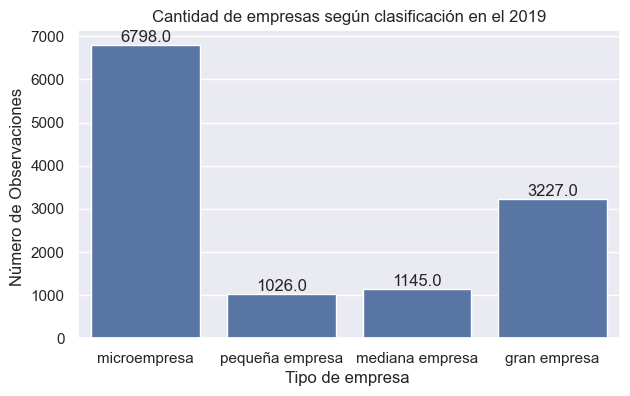

In [4]:
sns.set( style="darkgrid" )
# sns.set( style="whitegrid" )
#figure size

fig, ax = plt.subplots( figsize=(7,4) )

x = sns.countplot( x="empresa", data=enaho[enaho['year'] == "2019" ] )

# Iterar sobre las barras
for p in ax.patches:
    # Obtener la posición y la altura de la barra
    height = p.get_height()
    # Colocar el texto sobre la barra
    ax.text(p.get_x() + p.get_width() / 2., height + 0.1, '{}'.format(height), ha='center', va='bottom')
    
plt.title('Cantidad de empresas según clasificación en el 2019')
plt.xlabel('Tipo de empresa ')
plt.ylabel('Número de Observaciones ')

###### Vertical Countplot and one color (red)

Text(0, 0.5, 'Tipo de empresa')

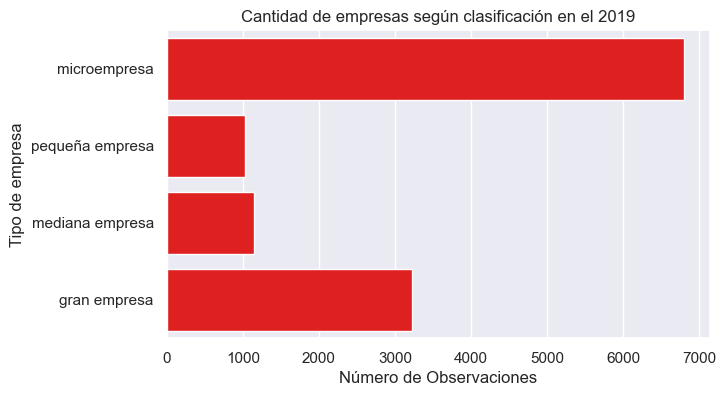

In [5]:
sns.set(style="darkgrid")
fig, ax = plt.subplots(figsize=(7,4))

x = sns.countplot(y = "empresa", data=enaho[enaho['year'] == "2019" ], color = 'red')

plt.title('Cantidad de empresas según clasificación en el 2019')
plt.xlabel('Número de Observaciones')
plt.ylabel('Tipo de empresa')

### Evolutions of business in period 2017-2019



Text(0.01, 0.01, 'Fuente: Elboración propia - ENAHO (2011-2019)')

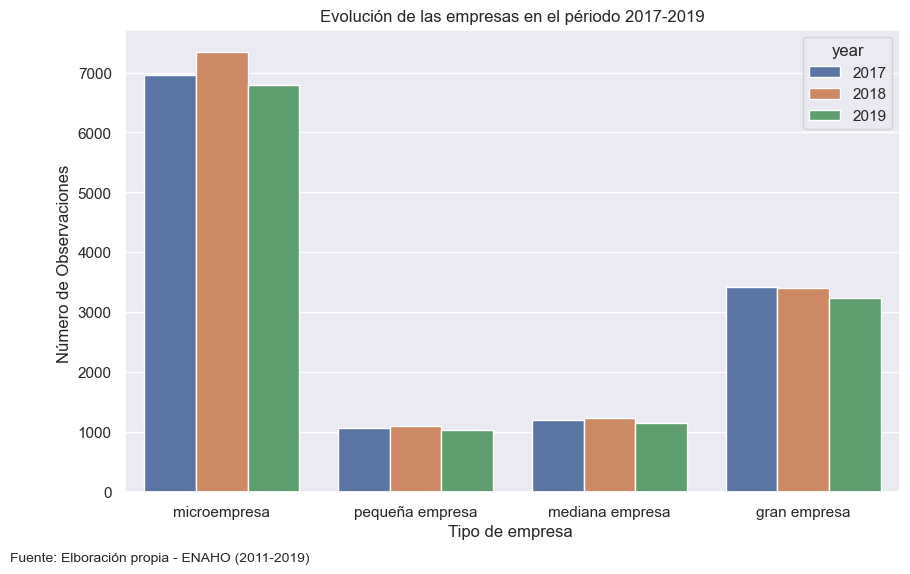

In [7]:
base2 = enaho[enaho['year'] > "2016" ]

fig, ax = plt.subplots(figsize=(10,6))

# hue: variable descomposition

ax = sns.countplot(x="empresa", hue="year", linewidth=1, data=base2)

plt.title('Evolución de las empresas en el périodo 2017-2019')
plt.xlabel('Tipo de empresa ')
plt.ylabel('Número de Observaciones ')

txt="Fuente: Elboración propia - ENAHO (2011-2019)"  
plt.figtext(0.01, 0.01, txt, wrap=True, horizontalalignment='left', va="top", fontsize=10)

### Number of companies by strata (urbano o rural) and evolution by years

hue = split in groups but in the same graph <br>
col = create two new groups base in id group

In [17]:
base2.area

103666    Urbana
103667     Rural
103668    Urbana
103669    Urbana
103670    Urbana
           ...  
160767    Urbana
160768    Urbana
160769    Urbana
160770    Urbana
160771    Urbana
Name: area, Length: 57106, dtype: category
Categories (2, object): ['Rural' < 'Urbana']

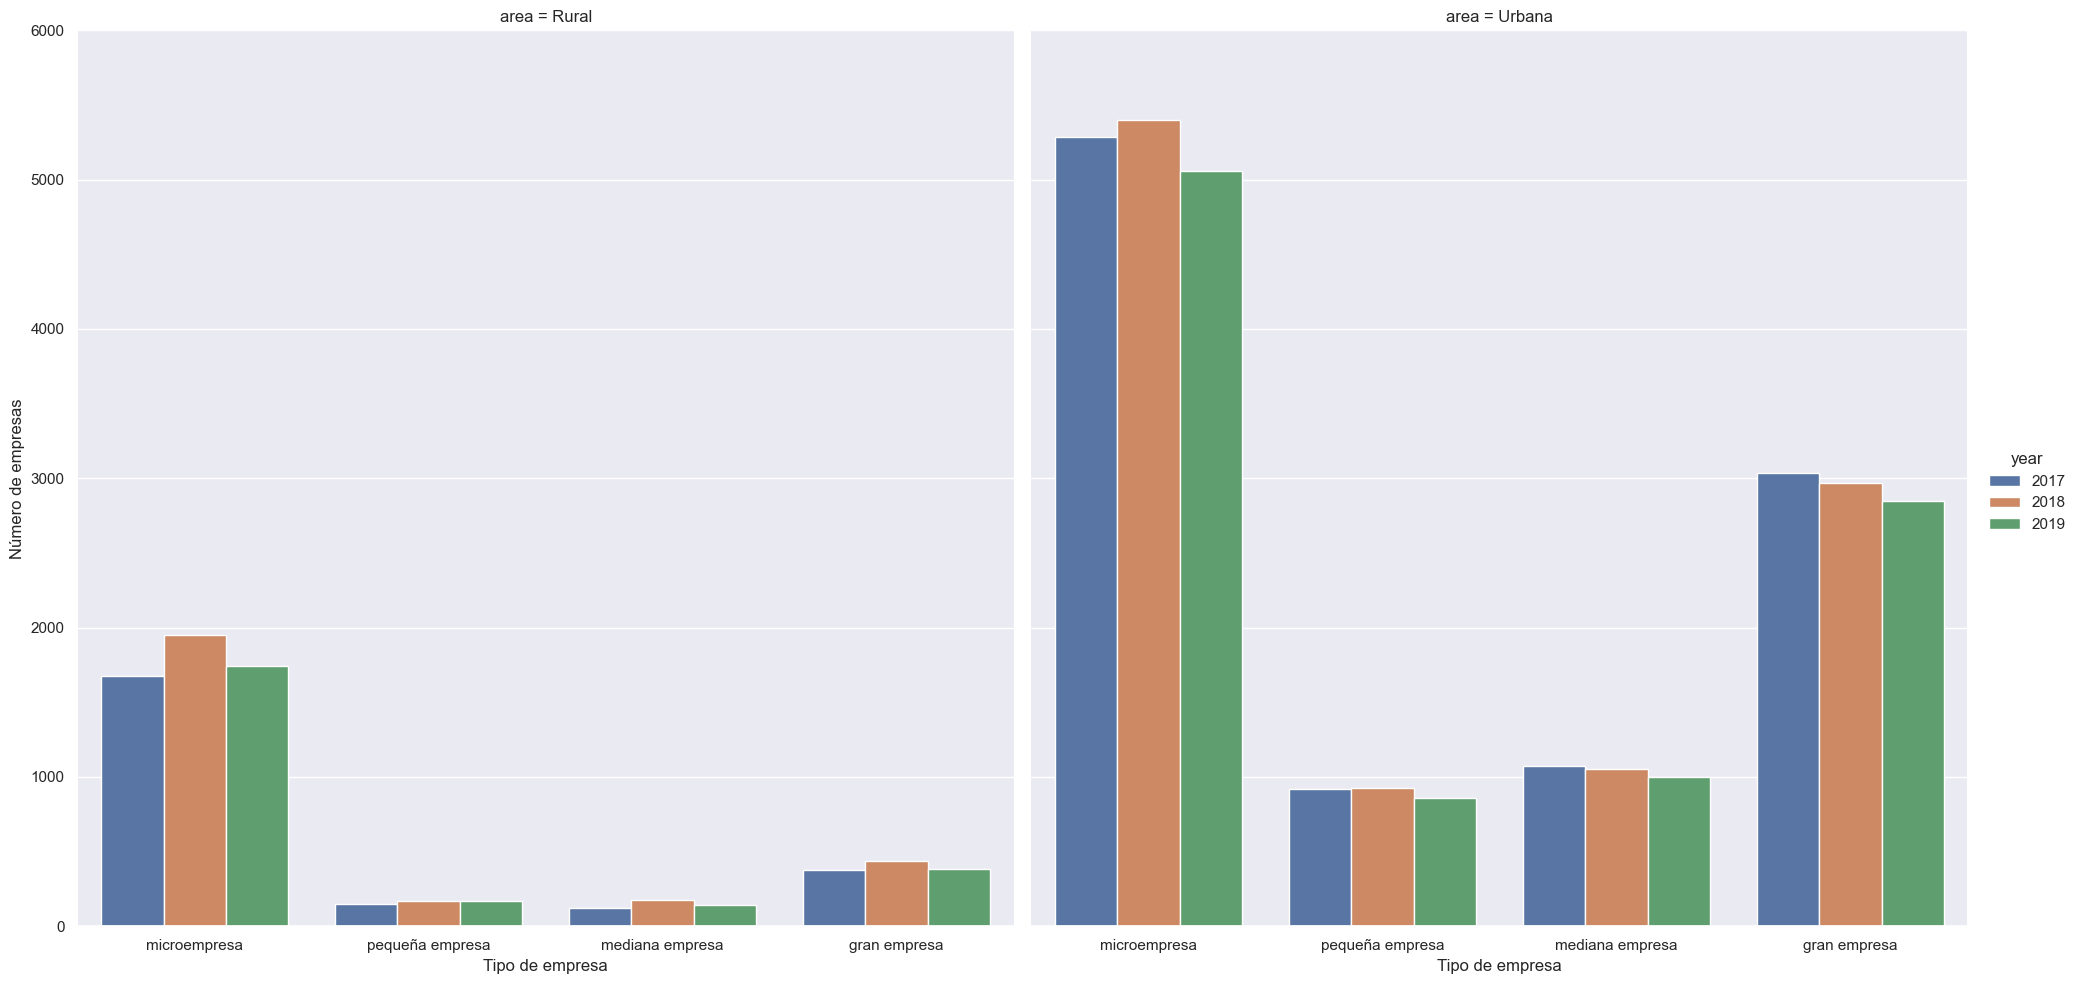

In [26]:
ag = sns.catplot(x="empresa", hue="year", col= "area" , data= base2, kind="count", height=10, aspect=1);

(ag.set_axis_labels("Tipo de empresa", "Número de empresas")
  .set(ylim=(0, 6000))
  .despine(left=True)) 

#### Number of businesses by strata - stacked bar plot

In [8]:
 enaho['conglome']

0           0061
1           0110
2           0090
3           0118
4           3408
           ...  
160767    009703
160768    009675
160769    009703
160770    009700
160771    009645
Name: conglome, Length: 160772, dtype: object

In [28]:
enaho[ enaho['year'] == "2019" ].groupby( [ 'empresa', 'area' ] ).size().reset_index(name='num_firms')

,empresa,area,num_firms
0,microempresa,Rural,1742
1,microempresa,Urbana,5056
2,pequeña empresa,Rural,169
3,pequeña empresa,Urbana,857
4,mediana empresa,Rural,145
5,mediana empresa,Urbana,1000
6,gran empresa,Rural,381
7,gran empresa,Urbana,2846


In [29]:
# count businesses by strata using groubpy (similar collapse - stata)
#base_2 = enaho[ enaho['year'] == "2019" ].groupby( [ 'empresa', 'area' ], as_index = False )[['conglome'] ].count()
base_2 = enaho[ enaho['year'] == "2019" ].groupby( [ 'empresa', 'area' ] ).size().reset_index(name='num_firms')
base_2

,empresa,area,num_firms
0,microempresa,Rural,1742
1,microempresa,Urbana,5056
2,pequeña empresa,Rural,169
3,pequeña empresa,Urbana,857
4,mediana empresa,Rural,145
5,mediana empresa,Urbana,1000
6,gran empresa,Rural,381
7,gran empresa,Urbana,2846


In [30]:
# stacked information
base_3 = base_2.pivot(index = 'empresa', columns = 'area', values = 'num_firms')
base_3

area,Rural,Urbana
empresa,,
microempresa,1742,5056
pequeña empresa,169,857
mediana empresa,145,1000
gran empresa,381,2846


In [31]:
base_3.columns

CategoricalIndex(['Rural', 'Urbana'], categories=['Rural', 'Urbana'], ordered=True, dtype='category', name='area')

In [32]:
base_3_2 = base_3.copy()

In [33]:
base_3_2 = base_3_2[["Urbana", "Rural"]]
base_3_2

area,Urbana,Rural
empresa,,
microempresa,5056,1742
pequeña empresa,857,169
mediana empresa,1000,145
gran empresa,2846,381


Text(0.5, 0, ' ')

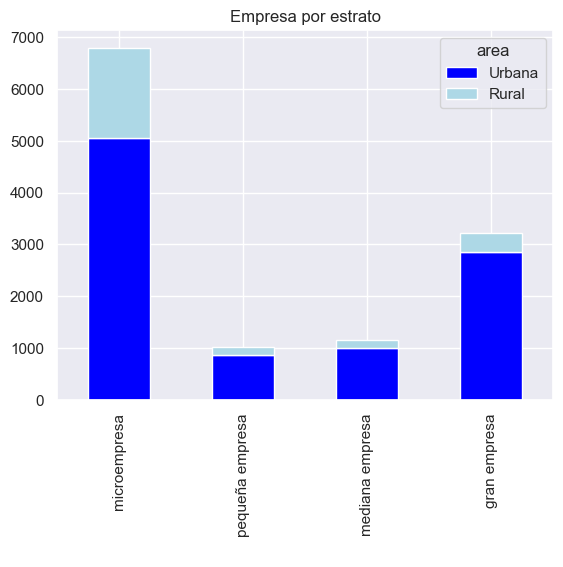

In [34]:
base_3_2.plot( kind='bar', stacked=True, title='Empresa por estrato', color = ['blue', 'lightblue'] )
plt.xlabel(' ')

Text(0.5, 0, ' ')

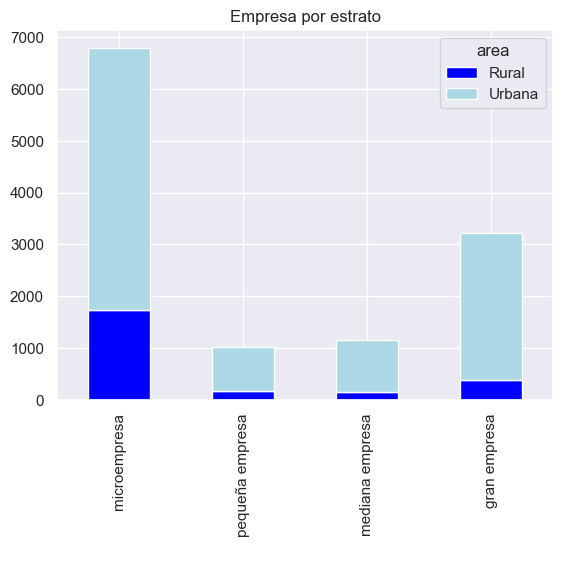

In [35]:
base_3.plot( kind='bar', stacked=True, title='Empresa por estrato', color = ['blue', 'lightblue'] )
plt.xlabel(' ')

(array([0, 1, 2, 3]),
 [Text(0, 0, 'microempresa'),
  Text(1, 0, 'pequeña empresa'),
  Text(2, 0, 'mediana empresa'),
  Text(3, 0, 'gran empresa')])

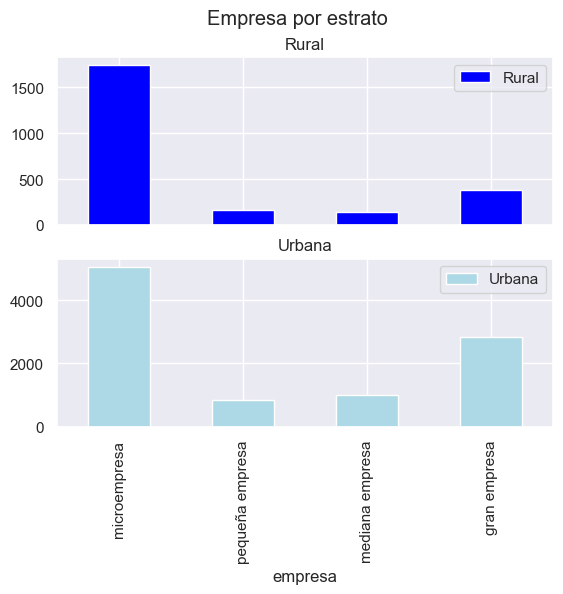

In [36]:
axes = base_3.plot( kind='bar', rot=0, subplots=True, color = ['blue', 'lightblue'], title='Empresa por estrato')
plt.xticks(rotation=90)

## 2. Proportions

Understandable plots to show categorical variables. Use this plots to explain participations from categories. 

### Pie 

##### First at all, collapse dataframe to count categories of a variable 

In [37]:
base = enaho.groupby([ 'empresa' ]).count()
base

,year,conglome,vivienda,hogar,ubigeo,codperso,dominio,estrato,panel,p203,...,acumulado,estud,educa,d_edu,exper,exper_2,tenure_2,edad_2,jefe,ubigeo_2
empresa,,,,,,,,,,,,,,,,,,,,,
microempresa,58002,58002,58002,58002,58002,58002,58002,58002,58002,58002,...,57991,58002,57991,57991,57565,57565,58001,58002,58002,58002
pequeña empresa,9306,9306,9306,9306,9306,9306,9306,9306,9306,9306,...,9301,9306,9301,9301,9202,9202,9303,9306,9306,9306
mediana empresa,10304,10304,10304,10304,10304,10304,10304,10304,10304,10304,...,10302,10304,10302,10302,10212,10212,10304,10304,10304,10304
gran empresa,29642,29642,29642,29642,29642,29642,29642,29642,29642,29642,...,29639,29642,29639,29639,29392,29392,29640,29642,29642,29642


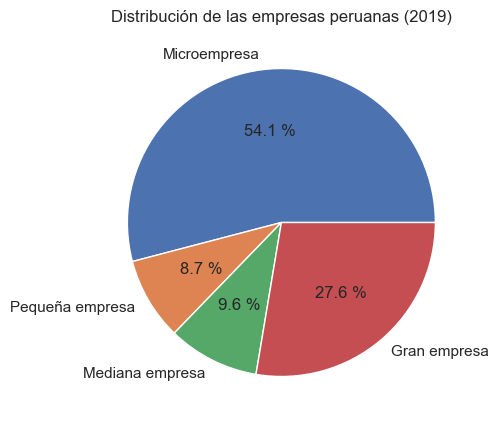

In [38]:
# Labels to correct categories names 

labels=['Microempresa','Pequeña empresa' , 'Mediana empresa', 'Gran empresa']

plt.figure(figsize=(5,5))

ax = plt.pie(base['conglome'], labels=labels, autopct='%.1f %%')
plt.title('Distribución de las empresas peruanas (2019)')
plt.show()

In [39]:
enaho.labor

0                                                       NaN
1                                   Ocupaciones elementales
2         Trabajo en actividades agrícolas, selvicultura...
3                                                       NaN
4                     Trabajadores de ventas y en servicios
                                ...                        
160767                                                  NaN
160768                              Ocupaciones elementales
160769                    Operadores de planta y maquinaria
160770                                                  NaN
160771                Trabajadores de ventas y en servicios
Name: labor, Length: 160772, dtype: category
Categories (9, object): ['Ocupaciones elementales' < 'Administradores' < 'Profesionales y fuerzas armadas' < 'Técnicos y similares' ... 'Trabajadores de ventas y en servicios' < 'Trabajo en actividades agrícolas, selvicultur... < 'Trabajo en artesanía y afines' < 'Operadores de planta y maquina

In [40]:
base = enaho.groupby('labor').size()
base

labor
Ocupaciones elementales                                   25556
Administradores                                           11310
Profesionales y fuerzas armadas                            1958
Técnicos y similares                                      12414
Asistentes administrativos                                14423
Trabajadores de ventas y en servicios                     18691
Trabajo en actividades agrícolas, selvicultura y pesca     5224
Trabajo en artesanía y afines                              8648
Operadores de planta y maquinaria                         11794
dtype: int64

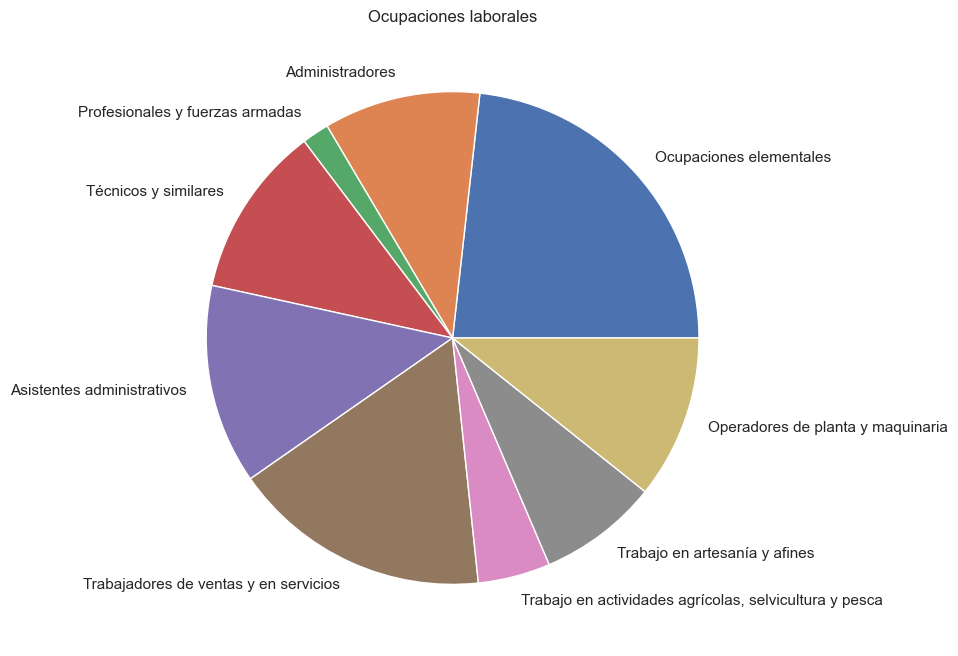

In [41]:
base = enaho.groupby('labor').size()
base.plot(kind='pie', subplots=True, figsize=(8, 8))
plt.title("Ocupaciones laborales")
plt.ylabel("")
plt.show()

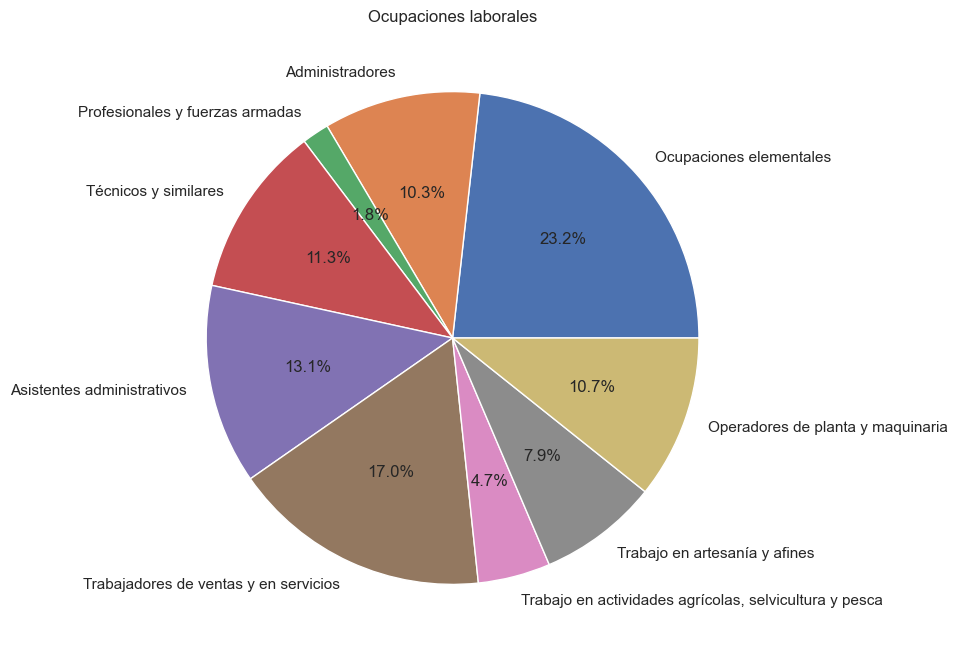

In [9]:
base = enaho.groupby('labor').size()
base.plot(kind='pie', subplots=True, figsize=(8, 8), autopct='%1.1f%%')  # Agregar el formato de porcentaje
plt.title("Ocupaciones laborales")
plt.ylabel("")
plt.show()

## Donuts

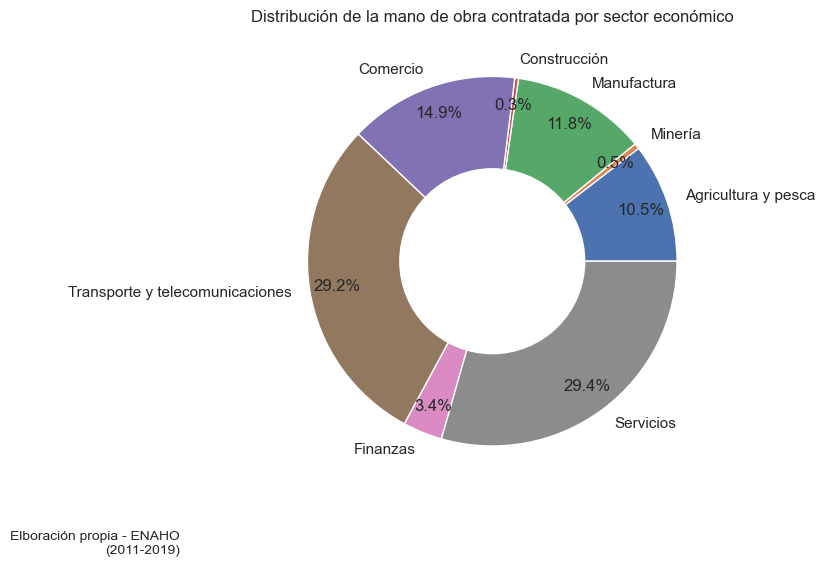

In [42]:
base2 = enaho.groupby([ 'sector' ]).count()

labels=['Agricultura y pesca','Minería','Manufactura','Construcción','Comercio','Transporte y telecomunicaciones', 'Finanzas', 'Servicios']
plt.figure(figsize=(10, 6))

ax = plt.pie(base2['conglome'], labels=labels,
        autopct='%1.1f%%', pctdistance=0.85)
  
# centroid size and color

center_circle = plt.Circle((0, 0), 0.50, fc='white')
fig = plt.gcf()

fig.gca().add_artist(center_circle)
  
plt.title('Distribución de la mano de obra contratada por sector económico')

# Adding notes

txt="Elboración propia - ENAHO (2011-2019)"  
plt.figtext(0.2, 0.01, txt, wrap=True, horizontalalignment='right', fontsize=10)

plt.show()

## 3. Distributions

Distribution plots visually assess the distribution of sample data by comparing the empirical distribution of the data with the theoretical values expected from a specified distribution.

In [10]:
#filter database to 2019
base4 = enaho[enaho['year'] == "2019" ]


<Axes: >

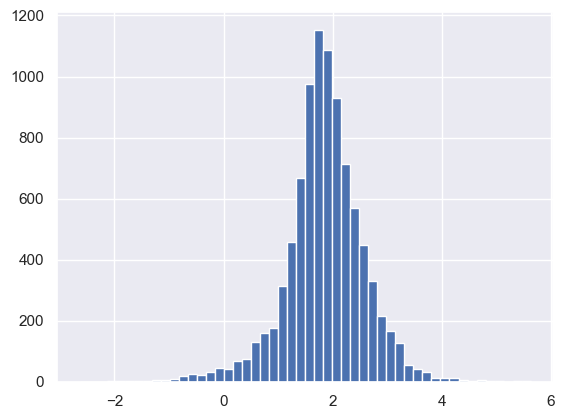

In [11]:
base4.l_salario.hist(bins=50)

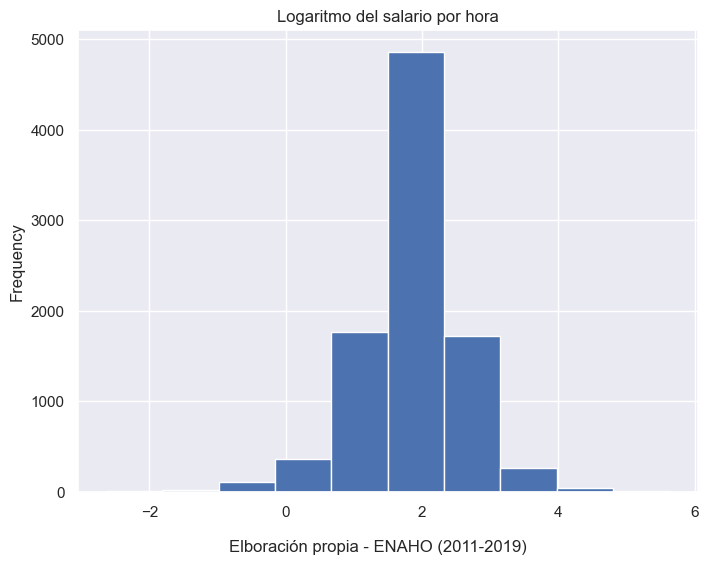

In [46]:
#filter database to 2019
base4 = enaho[enaho['year'] == "2019" ]

base4['l_salario'].plot(kind = 'hist', bins = 10, figsize = (8,6))
plt.title('Logaritmo del salario por hora')

txt="Elboración propia - ENAHO (2011-2019)"  
plt.figtext(0.5, 0.01, txt, wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

### Reducing intervals 

Frequency distribution with a smaller interval (lower relative frequency). Therefore, the height of each bar accounts smaller amount.

In [14]:
base4['l_salario']

142727    0.330982
142728         NaN
142729         NaN
142730    0.136815
142731         NaN
            ...   
160767         NaN
160768    1.981469
160769    2.278091
160770         NaN
160771    0.657769
Name: l_salario, Length: 18045, dtype: float32

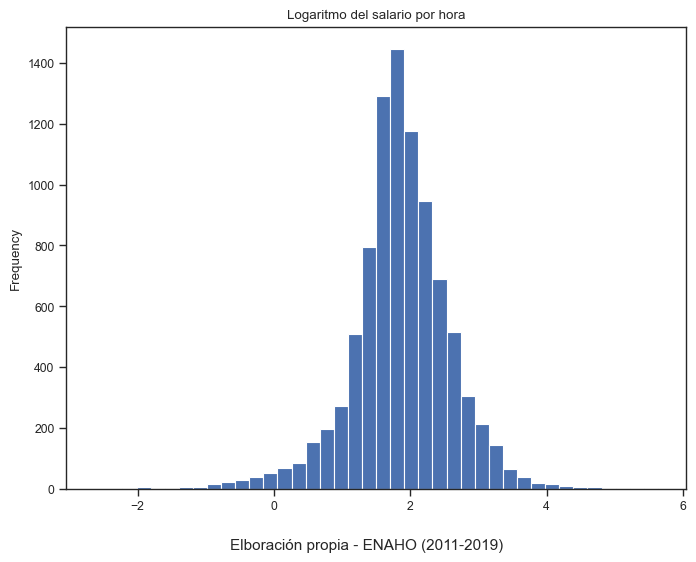

In [12]:
sns.set('paper')
sns.set_style("ticks")

base4['l_salario'].plot(kind = 'hist', bins = 40, figsize = (8,6))
plt.title('Logaritmo del salario por hora')

txt="Elboración propia - ENAHO (2011-2019)"  
plt.figtext(0.5, 0.01, txt, wrap=True, horizontalalignment='center', fontsize=11)
plt.show()

### Multiple histograms

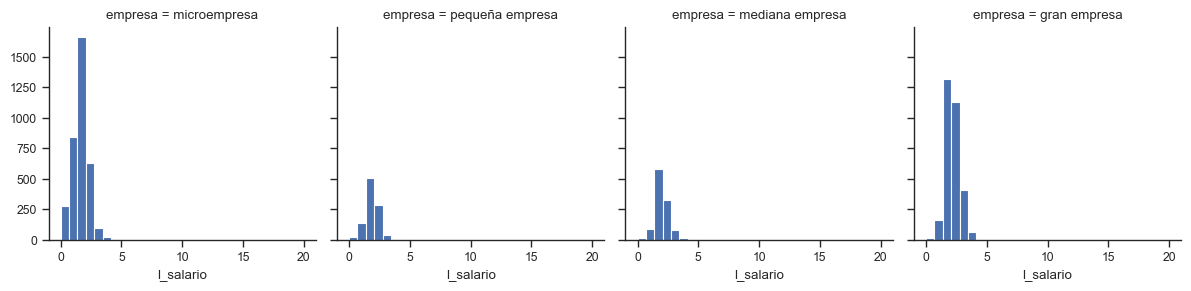

In [48]:
figure1 = sns.FacetGrid(base4, col="empresa", margin_titles=True)
figure1.map(plt.hist, 'l_salario', bins=np.linspace(0, 20, 30))

##### Real salary per hour density: 
the distribution does not resemble a standard normal. The information is concentrated in lower values and there are some observations of high values.

C:\Users\melor\AppData\Local\Temp\ipykernel_7844\223923443.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(base4['salario'], label = "Densidad", color = 'blue')


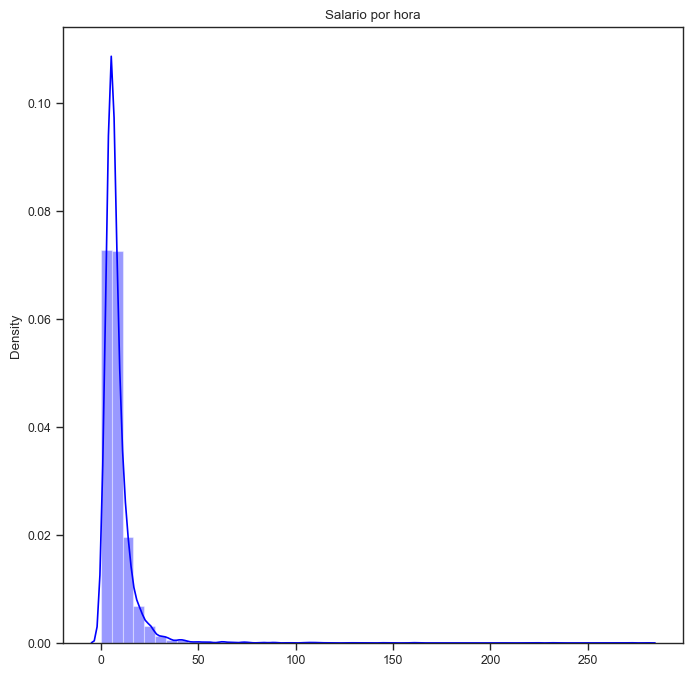

In [49]:
plt.figure(figsize=(8, 8))

sns.distplot(base4['salario'], label = "Densidad", color = 'blue')
plt.title('Salario por hora')
plt.xlabel(' ')
plt.show()

### Logarithm of real hourly wage

This allows correcting the asymmetry presented by the original data.

C:\Users\melor\AppData\Local\Temp\ipykernel_7844\989620771.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(base4['l_salario'], label = "Densidad", color = 'black')


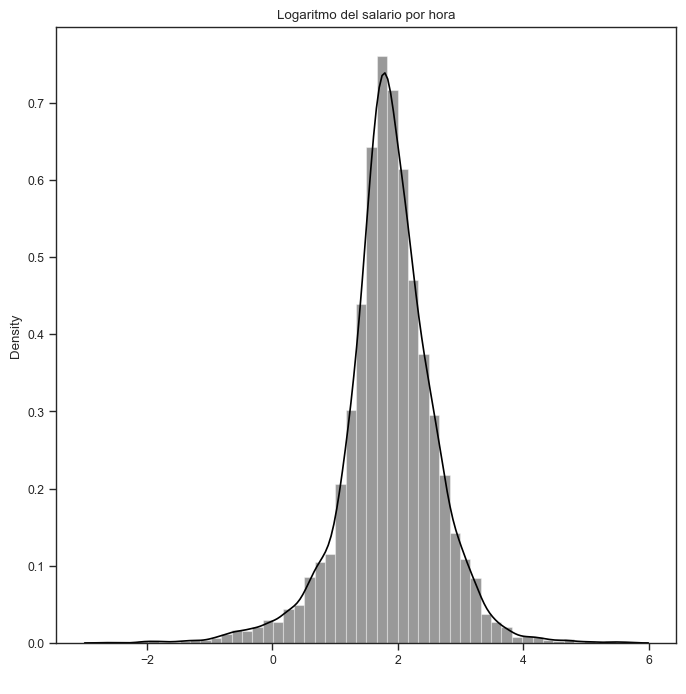

In [50]:
#Alternative figure size
plt.figure(figsize=(8, 8))

sns.distplot(base4['l_salario'], label = "Densidad", color = 'black')
plt.title('Logaritmo del salario por hora')
plt.xlabel(' ')
plt.show()

#### Real salaries for tres sectors (Construction, Mining and services)


In [51]:
base4.sector

142727    agricultura, selvicultura y pesca
142728                                  NaN
142729                                  NaN
142730    agricultura, selvicultura y pesca
142731                                  NaN
                        ...                
160767                                  NaN
160768     Comercio, hoteles y restaurantes
160769     Comercio, hoteles y restaurantes
160770                                  NaN
160771     Comercio, hoteles y restaurantes
Name: sector, Length: 18045, dtype: category
Categories (8, object): ['agricultura, selvicultura y pesca' < 'minería' < 'Manufactura y servicios públcios' < 'Construcción' < 'Comercio, hoteles y restaurantes' < 'Transporte, comunicaciones y alamacenamiento' < 'Finanzas, seguro y bienes raíces' < 'Servicios persnales, sociales y comunales']

C:\Users\melor\AppData\Local\Temp\ipykernel_7844\5583352.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(base4.l_salario[base4.sector=='Construcción'], label='Construcción', shade=True, color="blue")
C:\Users\melor\AppData\Local\Temp\ipykernel_7844\5583352.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(base4.l_salario[base4.sector=='Comercio, hoteles y restaurantes'], label='Comercio, hoteles y restaurantes', shade=True, color = "red")
C:\Users\melor\AppData\Local\Temp\ipykernel_7844\5583352.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(base4.l_salario[base4.sector=='minería'], label='Minería ', shade=Tru

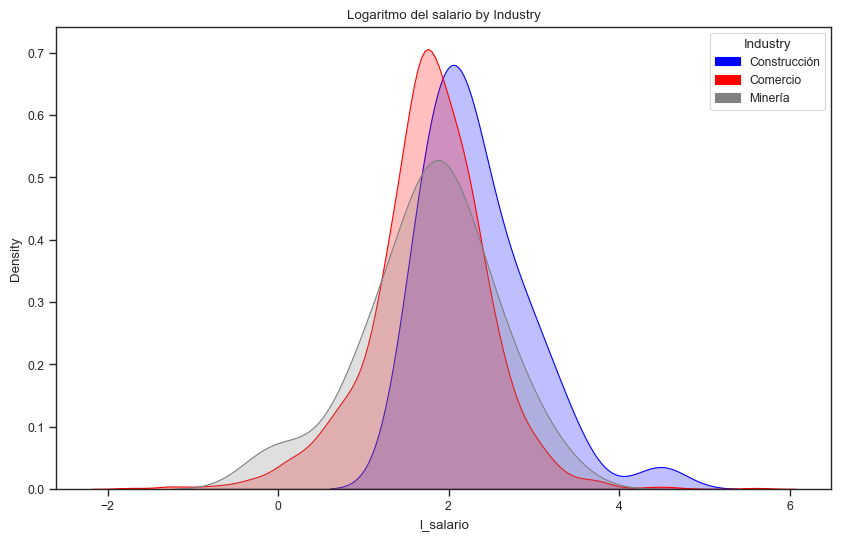

In [52]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 6))

#Adding densities 

sns.kdeplot(base4.l_salario[base4.sector=='Construcción'], label='Construcción', shade=True, color="blue")
sns.kdeplot(base4.l_salario[base4.sector=='Comercio, hoteles y restaurantes'], label='Comercio, hoteles y restaurantes', shade=True, color = "red")
sns.kdeplot(base4.l_salario[base4.sector=='minería'], label='Minería ', shade=True, color="gray")
plt.title('Logaritmo del salario by Industry')

# Define custom colors
color1 = 'blue'
color2 = 'red'
color3 = "gray"
# Create legend handles
handle1 = mpatches.Patch(color=color1, label='Construcción')
handle2 = mpatches.Patch(color=color2, label='Comercio')
handle3 = mpatches.Patch(color=color3, label='Minería')

# Manually adding a legend with custom colors
plt.legend(handles=[handle1, handle2, handle3], title='Industry')
# Construction sector shows certain stochastic dominance over mining and services

### Labor occupations and real salary per hour densities

A For loop is used to include in the same graph the density function of hourly wages for different occupations.

C:\Users\melor\AppData\Local\Temp\ipykernel_18632\97906598.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(base4.l_salario[base4.labor==a], label=b, shade=True, color = c)
C:\Users\melor\AppData\Local\Temp\ipykernel_18632\97906598.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(base4.l_salario[base4.labor==a], label=b, shade=True, color = c)
C:\Users\melor\AppData\Local\Temp\ipykernel_18632\97906598.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(base4.l_salario[base4.labor==a], label=b, shade=True, color = c)
C:\Users\melor\AppData\Local\Temp\ipykernel_18632\97906598.py:12: FutureWarning: 

`shade` is now

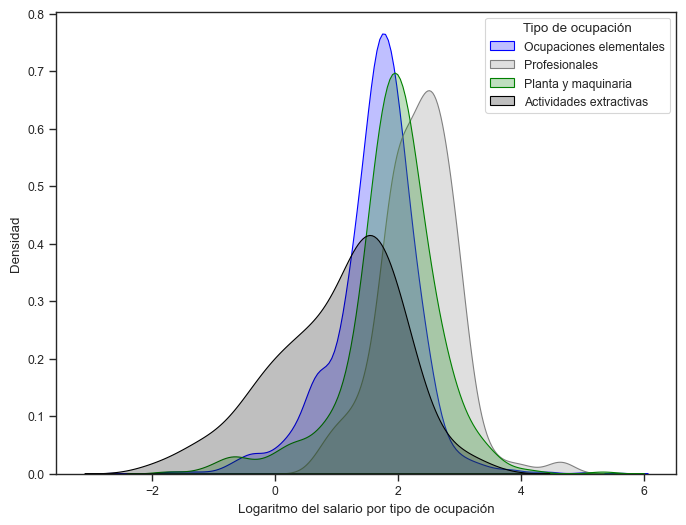

In [16]:
fig, ax = plt.subplots(figsize=(8,6))

sector = [ 'Ocupaciones elementales', 'Profesionales y fuerzas armadas', 'Operadores de planta y maquinaria',
          'Trabajo en actividades agrícolas, selvicultura y pesca']

nombre = [ 'Ocupaciones elementales', 'Profesionales', 'Planta y maquinaria','Actividades extractivas']

color = [ 'blue', 'gray', 'green','black']

    
for a, b, c in zip(sector, nombre, color):
        sns.kdeplot(base4.l_salario[base4.labor==a], label=b, shade=True, color = c)

plt.xlabel('Logaritmo del salario por tipo de ocupación')

plt.ylabel('Densidad')

# Añadir leyenda
plt.legend(title='Tipo de ocupación')

plt.show()

# Two relevant findings: stochastic dominance of the salary of professionals and 
# concentration in lower levels of salary in the non-active primary sector.

### Box plot real salary and education 



[Text(0, 0, 'Sec. completa'),
 Text(1, 0, 'No uni. incompleta'),
 Text(2, 0, 'No uni. completa'),
 Text(3, 0, 'Uni. incompleta'),
 Text(4, 0, 'Uni. completa'),
 Text(5, 0, 'Posgrado')]

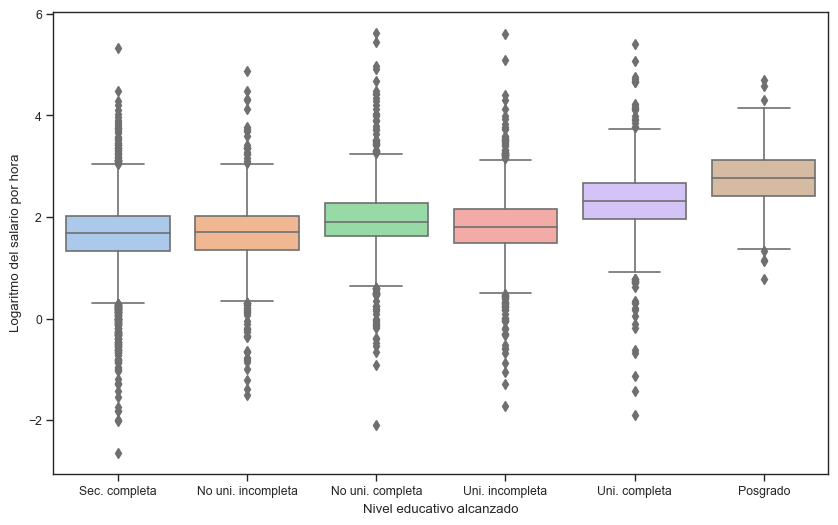

In [54]:
fig, ax = plt.subplots(figsize=(10,6))

box = sns.boxplot(x="educ", y="l_salario", data=enaho[enaho['year'] == "2019" ] ,palette='pastel')
plt.xlabel('Nivel educativo alcanzado')
plt.ylabel('Logaritmo del salario por hora')
(box.set_xticklabels(["Sec. completa", "No uni. incompleta", "No uni. completa", "Uni. incompleta", "Uni. completa", "Posgrado"]))\

# The real wage quartiles are increasing with the educational level.
# Lower salary dispersion for the postgraduate level. pastel


## 4. Relationships

Charts used for both time series and cross-sectional data. These graphs allow to establish certain evidence of correlation or relationships between variables.

### Scatter plot 

First, a random sample is drawn from the original database. Subsequently, a dispersion graph is presented between the hourly wage (logarithm) and the non-labor monthly income (logarithm).

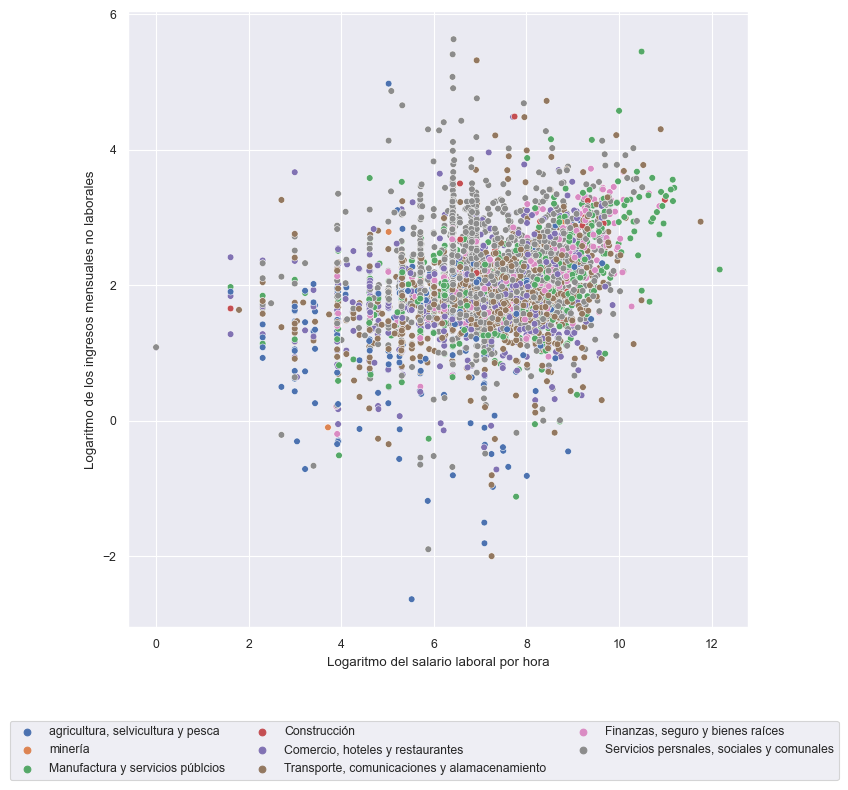

In [55]:
#Full sample

sns.set('paper')
plt.figure(figsize=(8, 8))
plot = sns.scatterplot(data=base4, x="l_n_labor", y="l_salario", hue="sector", palette="deep")

plt.xlabel('Logaritmo del salario laboral por hora')
plt.ylabel('Logaritmo de los ingresos mensuales no laborales')

# By default legend inside plot. Following codes allow us to put outside. 
# bbox_to_anchor: box location
# ncol: # columns of legend



plot.legend(loc='center left', bbox_to_anchor=(-0.2, -0.2), ncol=3)

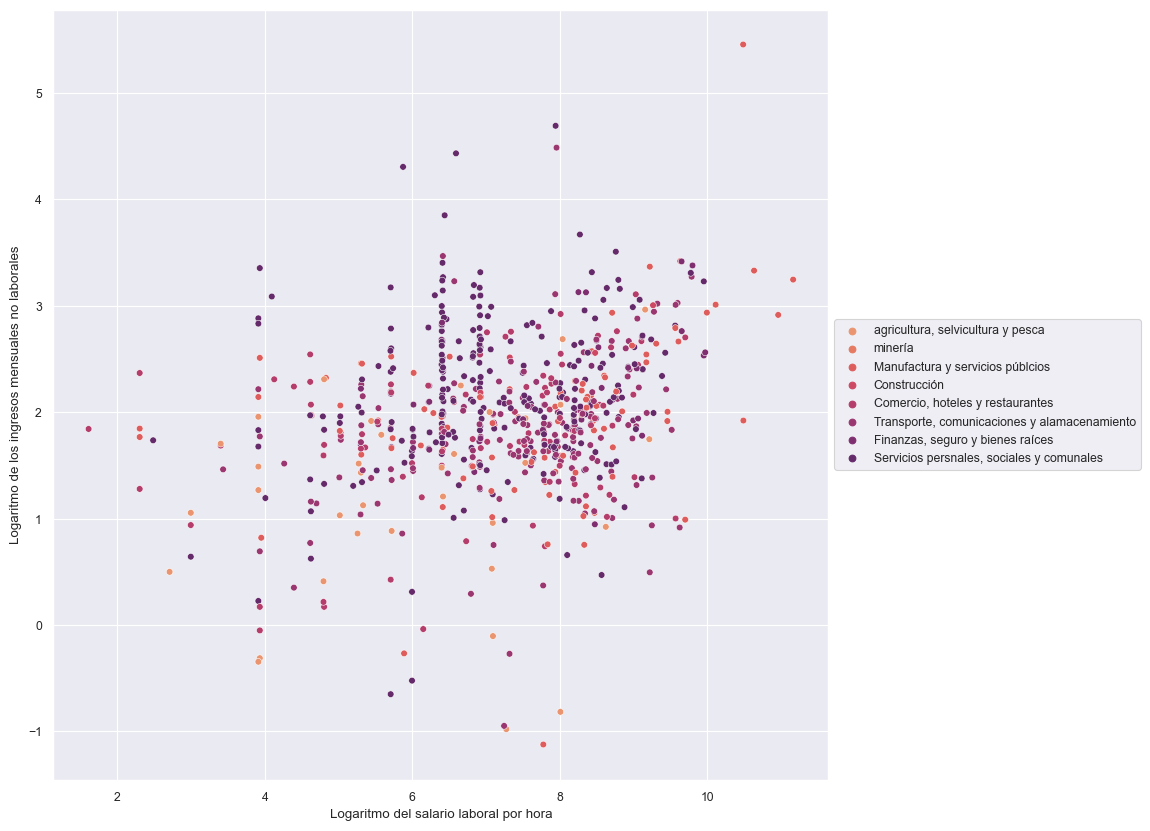

In [56]:
# Ramdon sample n = 3000

base5 = base4.sample(n = 3000)

sns.set('paper')
plt.figure(figsize=(10, 10))
plot = sns.scatterplot(data=base5, x="l_n_labor", y="l_salario", hue="sector", palette="flare")

plt.xlabel('Logaritmo del salario laboral por hora')
plt.ylabel('Logaritmo de los ingresos mensuales no laborales')

plot.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

#### Reggresion real salary per hour and  non-labor income by strata

s = The marker size in points**2. <br>
linewidths = "The linewidth of the marker edges."

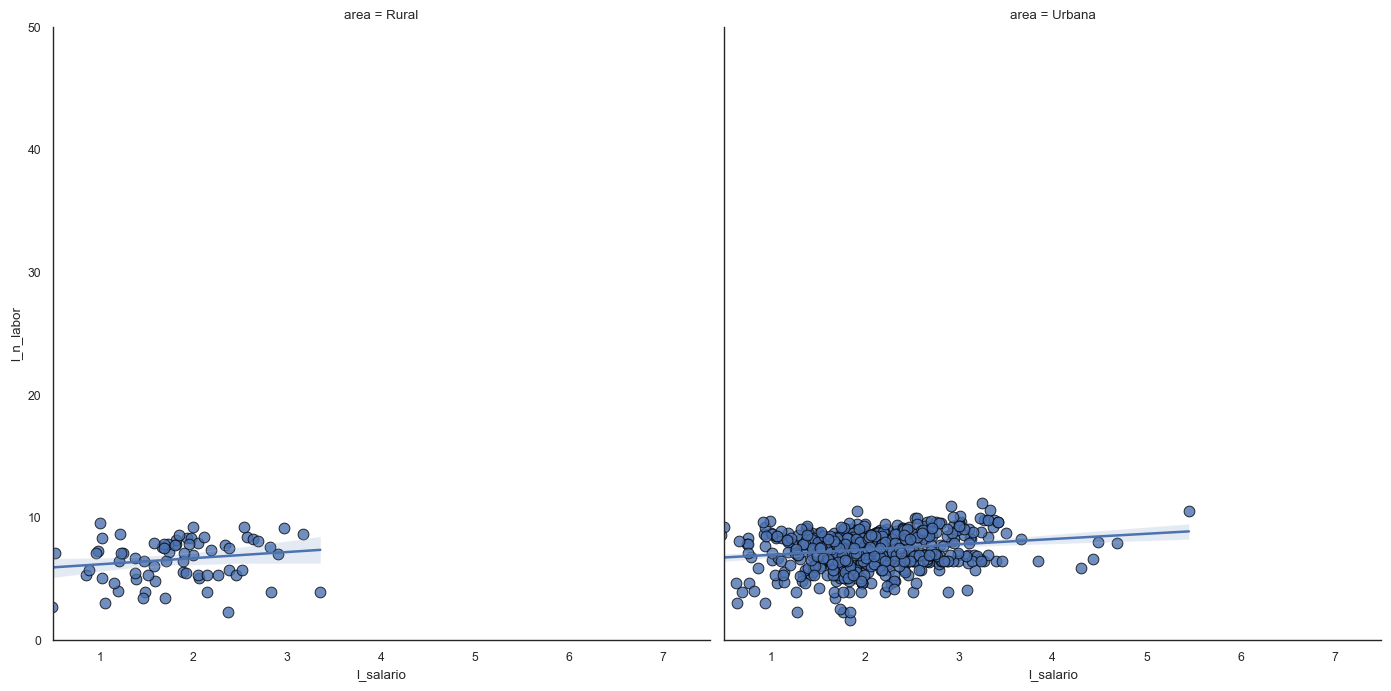

In [57]:
sns.set_style("white")
gridobj = sns.lmplot(x="l_salario", y="l_n_labor", 
                     data=base5, 
                     height=7, 
                     robust=True, 
                     palette='Set1', 
                     col="area",
                     scatter_kws=dict(s=60, linewidths=0.7, edgecolors='black'))

gridobj.set(xlim=(0.5, 7.5), ylim=(0, 50))
plt.show()

<Axes: xlabel='l_salario', ylabel='l_n_labor'>

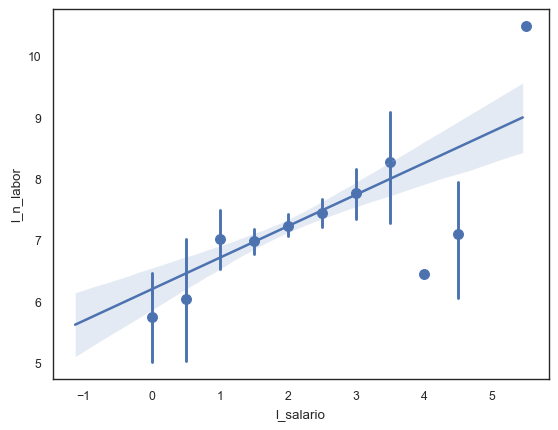

In [58]:
sns.regplot(data=base5, x="l_salario", y="l_n_labor", x_bins=np.arange(0, 7, 0.5), order=1)